# 📌 실험 1. Close-only 단일 피처 시계열 예측

## ✅ 목적
- 가장 단순한 baseline 설계
- 종가(Close) 단일 피처만 사용
- 과거 3일치 종가를 입력해 다음날 종가를 예측
- 기술적 지표 없이 순수 가격 정보만으로 예측 성능 확인

---

## ✅ 데이터 학습 정보
- 종목: Apple (AAPL)
- 기간: 2017-11 ~ 2025-06
- Train/Test 분할:
  - Train: 2017-11 ~ 2023-08
  - Test: 2023-09 이후
- 입력 피처: Close 단일 값
- 시계열 윈도우 길이: 3
- 스케일링: MinMaxScaler

---

## ✅ 사용 모델
- Keras LSTM 기반 시계열 회귀
- 구조:
  - LSTM(100)
  - Dropout(0.2)
  - Dense(1)
- Optimizer: Adam
- 손실함수: MSE
- Epochs: 100
- Batch size: 10
- EarlyStopping 적용

---

## ✅ 피처 생성 및 전처리
- Train/Test 분리 후 scaler.fit/transform 적용 (누수 방지)
- 시계열 윈도우 생성:
  - 과거 3일 Close → 다음날 Close 예측

---

## ✅ 모델 성능 결과 (2023-09 이후 Test Set)
- RMSE: 7.08 달러
- MAE: 5.86 달러
- R²: 0.915
- MAPE: 2.86%

---

## ✅ 시각적 결과 해석
- 예측 라인이 실제 가격 움직임을 잘 추적
- 트렌드와 주요 변동 구간을 일정 부분 따라감
- 큰 가격 레벨 변화에서도 일정 수준의 예측력 유지
- 스무스하지만 drift 문제는 일부 존재

---

## ✅ 문제점 / 한계
- 입력 정보가 **종가 단일 피처**로 한정 → 시장의 다른 신호 반영 불가
- 과거 3일치 정보만 사용 → 장기적인 트렌드 변화 학습 한계
- 가격의 절대 레벨(레벨 시프트)에 대한 예측력은 제한적
- Drift Copying 문제는 줄였으나, 여전히 예측이 평균 수준으로 회귀하는 경향

---

## ✅ 인사이트
- 가격만으로도 일정 수준의 단기 패턴 예측은 가능함을 확인
- 그러나 종가 단일 피처만으로는 시장의 전반적인 구조적 변화를 반영하기 어렵다는 한계가 분명

---

## ✅ 향후 개선 방향

1. **입력 시퀀스 확장**  
   - 단기 3일 → 중장기 20~60일 윈도우  
   - 더 긴 과거 정보를 활용해 트렌드 학습

2. **기술적 지표 추가**  
   - RSI, MACD, OBV, Bollinger Bands 등 주요 지표를 피처로 확장  
   - 단일 종가의 한계를 극복하고 패턴/모멘텀/거래량 정보를 통합

3. **데이터 전처리 개선**  
   - 로그변환, 차분 → 레벨 시프트 문제 제거  
   - 수익률 기반 타겟 설계

4. **다양한 모델 아키텍처 실험**  
   - LSTM의 층 수와 노드 수 조정  
   - GRU, Transformer 계열 모델 도입  
   - Dropout과 조기 종료(EarlyStopping) 전략 강화

---

/tmp/ipykernel_9482/632134870.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date)[['Close']].dropna()
[*********************100%***********************]  1 of 1 completed

Price        Date      Close
Ticker                  AAPL
0      2017-11-01  39.026264
1      2017-11-02  39.311565
2      2017-11-03  40.338131
3      2017-11-06  40.747360
4      2017-11-07  40.878326
Train: (1467, 2) Test: (460, 2)
x_train: (1464, 3, 1) y_train: (1464,)
x_test: (460, 3, 1) y_test: (460,)
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_14 (LSTM)              (None, 100)               40800     
                                                                 
 dropout_14 (Dropout)        (None, 100)               0         
                                                                 
 dense_5 (Dense)             (None, 1)                 101       
                                                                 
Total params: 40,901
Trainable params: 40,901
Non-trainable params: 0
_________________________________________________________________



2025-07-04 10:59:33.367641: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-04 10:59:33.368796: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-04 10:59:33.369627: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mu

Epoch 1/100


2025-07-04 10:59:33.612883: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-04 10:59:33.615697: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-04 10:59:33.617045: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

145/147 [============================>.] - ETA: 0s - loss: 0.0268 - mean_squared_error: 0.0268

2025-07-04 10:59:36.555393: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-04 10:59:36.558330: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-04 10:59:36.559363: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

147/147 [==============================] - 3s 15ms/step - loss: 0.0266 - mean_squared_error: 0.0266 - val_loss: 0.0105 - val_mean_squared_error: 0.0105
Epoch 2/100
147/147 [==============================] - 2s 12ms/step - loss: 0.0017 - mean_squared_error: 0.0017 - val_loss: 0.0018 - val_mean_squared_error: 0.0018
Epoch 3/100
147/147 [==============================] - 2s 12ms/step - loss: 0.0016 - mean_squared_error: 0.0016 - val_loss: 0.0036 - val_mean_squared_error: 0.0036
Epoch 4/100
147/147 [==============================] - 2s 12ms/step - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0029 - val_mean_squared_error: 0.0029
Epoch 5/100
147/147 [==============================] - 2s 12ms/step - loss: 0.0013 - mean_squared_error: 0.0013 - val_loss: 0.0019 - val_mean_squared_error: 0.0019
Epoch 5: early stopping
15/15 [==============================] - 0s 5ms/step


2025-07-04 10:59:44.052035: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-04 10:59:44.053755: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-04 10:59:44.054927: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

✅ RMSE: 7.0799
✅ MAE: 5.8576
✅ R²: 0.9149
✅ MAPE: 2.86%
✅ predictions.csv 저장 완료


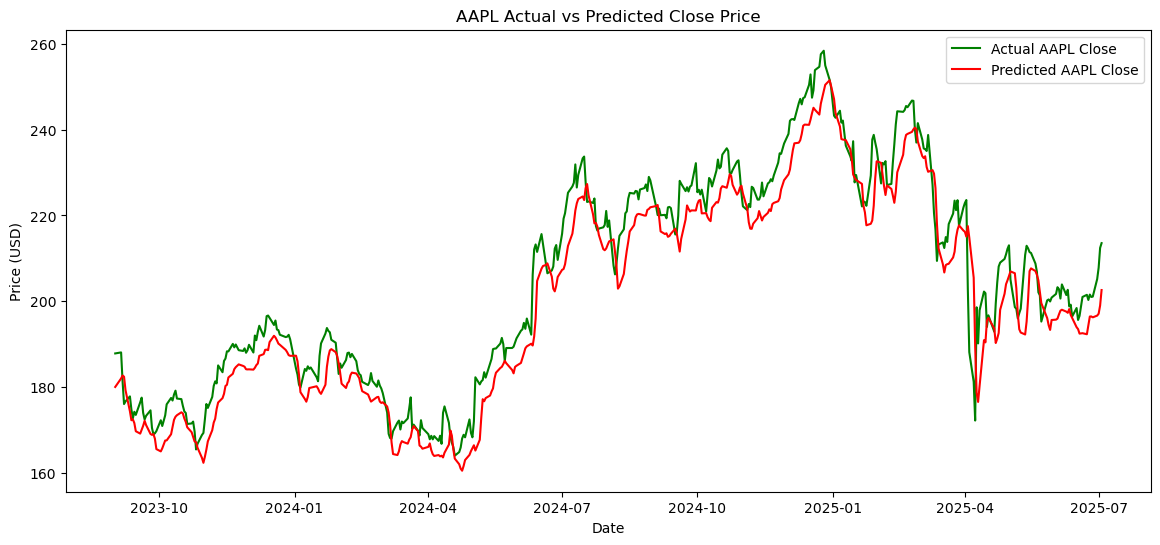

In [7]:
# ✅ 1️⃣ 라이브러리
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# ✅ 2️⃣ 파라미터
ticker = 'AAPL'
start_date = '2017-11-01'
validation_date = '2023-09-01'
epochs = 100
batch_size = 10
time_steps = 3

# ✅ 3️⃣ 데이터 다운로드
df = yf.download(ticker, start=start_date)[['Close']].dropna()
df = df.reset_index()
print(df.head())

# ✅ 4️⃣ Split
train_data = df[df['Date'] < validation_date].copy()
test_data = df[df['Date'] >= validation_date].copy()

print('Train:', train_data.shape, 'Test:', test_data.shape)

# ✅ 5️⃣ 스케일링
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data[['Close']])
test_inputs = pd.concat([train_data.tail(time_steps), test_data])
test_scaled = scaler.transform(test_inputs[['Close']])

# ✅ 6️⃣ 윈도우 생성
def create_windows(data, time_steps=3):
    x, y = [], []
    for i in range(time_steps, len(data)):
        x.append(data[i-time_steps:i])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

x_train, y_train = create_windows(train_scaled, time_steps)
x_test, y_test = create_windows(test_scaled, time_steps)

print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_test:', x_test.shape, 'y_test:', y_test.shape)

# ✅ 7️⃣ 모델 정의
model = Sequential()
model.add(LSTM(100, return_sequences=False, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])
model.summary()

# ✅ 8️⃣ 학습
callback = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test), callbacks=[callback])

# ✅ 9️⃣ 예측
predictions = model.predict(x_test)

# ✅ 10️⃣ 역변환
pred_inv = scaler.inverse_transform(np.concatenate([predictions, np.zeros((len(predictions), 0))], axis=1))[:,0]
y_test_inv = scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), 0))], axis=1))[:,0]

# ✅ 11️⃣ 평가
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"✅ RMSE: {rmse:.4f}")
    print(f"✅ MAE: {mae:.4f}")
    print(f"✅ R²: {r2:.4f}")
    print(f"✅ MAPE: {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

metrics = evaluate_metrics(y_test_inv, pred_inv)

# ✅ 12️⃣ 저장 - Jordi 방식에서 올바른 Date 매칭
results = pd.DataFrame({
    'Date': test_data['Date'].values,           # 이게 핵심! test 구간의 Date 그대로
    'Actual_Close': y_test_inv,
    'Predicted_Close': pred_inv
})
results.to_csv('aapl_lstm_predictions.csv', index=False)
print('✅ predictions.csv 저장 완료')


# ✅ 13️⃣ 시각화
plt.figure(figsize=(14,6))
plt.plot(results['Date'], results['Actual_Close'], label='Actual AAPL Close', color='green')
plt.plot(results['Date'], results['Predicted_Close'], label='Predicted AAPL Close', color='red')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('AAPL Actual vs Predicted Close Price')
plt.legend()
plt.show()


In [8]:
train_predictions = model.predict(x_train)

46/46 [==============================] - 0s 5ms/step


In [9]:
train_pred_inv = scaler.inverse_transform(
    np.concatenate([train_predictions, np.zeros((len(train_predictions), 0))], axis=1)
)[:,0]

y_train_inv = scaler.inverse_transform(
    np.concatenate([y_train.reshape(-1,1), np.zeros((len(y_train), 0))], axis=1)
)[:,0]


In [10]:
train_results = pd.DataFrame({
    'Date': train_data['Date'].iloc[time_steps:].values,
    'Actual_Close': y_train_inv,
    'Predicted_Close': train_pred_inv
})


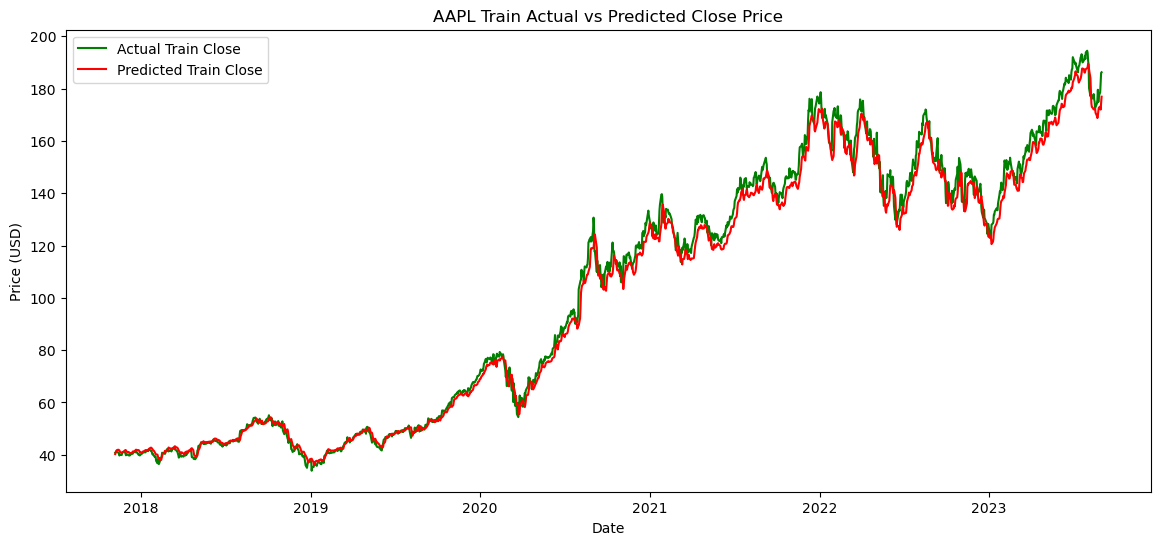

In [11]:
plt.figure(figsize=(14,6))
plt.plot(train_results['Date'], train_results['Actual_Close'], label='Actual Train Close', color='green')
plt.plot(train_results['Date'], train_results['Predicted_Close'], label='Predicted Train Close', color='red')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('AAPL Train Actual vs Predicted Close Price')
plt.legend()
plt.show()
